In [13]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='svg'

try:
    # This is robust against converting to a python script and running outside
    # of a jupyter notebook, where the %config magic command would fail.
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'svg'")
except Exception:
    pass

import mitsuba as mi
import drjit as dr

mi.set_variant('cuda_acoustic', 'llvm_acoustic', 'cuda_ad_acoustic', 'llvm_ad_acoustic')
print(f'Using variant: {mi.variant()}')
mi.set_log_level(mi.LogLevel.Warn)

from mitsuba import ScalarTransform4f as tf

Using variant: llvm_ad_acoustic


# Rendering with Atmospheric Data

<div class="admonition important alert alert-block alert-info">

💡 **Info:**

This tutorial demonstrates misuka's atmospheric-data-aware forward rendering (for inverse rendering see [atmosphere_optimization.ipynb](../inverse_rendering/atmosphere_optimization.ipynb)). The speed of sound and the frequency-dependent air attenuation (ISO 9613-1) both depend on the state of the propagation medium (temperature, humidity, pressure, ...). This notebook shows how to render with that in mind.

</div>

<div class="admonition important alert alert-block alert-success">

🚀 **You will learn how to:**

<ul>
  <li>Compute the speed of sound from atmospheric parameters</li>
  <li>Let the <code>acoustic_path</code> integrator apply atmospheric attenuation <b>during</b> rendering, using the <code>acoustic_medium</code> plugin parameter</li>
</ul>

</div>

## Scene setup

We reuse the shoebox room from the [Shoebox scene tutorial](../shoebox_scene.ipynb) — see that notebook for a full walkthrough of the scene-building API. The short version: six absorptive/scattering walls built from `rectangle` shapes and an `acousticbsdf`, wrapped around a spherical sound source.

In [14]:
room_dim       = np.array([6, 8, 4.0]) # length, width, height
emitter_pos    = np.array([3, 6, 1.2])
receiver_pos   = np.array([2, 1, 1.2])
emitter_radius = 0.5

absorption_top     = [(100, 0.1), (500, 0.5), (20000, 0.1)]
scattering_top     = [(100, 0.3), (500, 0.5), (20000, 0.8)]

absorption_bottom  = [(100, 0.4), (500, 0.5), (20000, 0.5)]
scattering_bottom  = [(100, 0.3), (500, 0.6), (20000, 0.9)]

absorption_left    = [(100, 0.0), (500, 0.4), (20000, 0.6)]
scattering_left    = [(100, 0.2), (500, 0.3), (20000, 0.4)]

absorption_right   = [(100, 0.2), (500, 0.4), (20000, 0.5)]
scattering_right   = [(100, 0.3), (500, 0.5), (20000, 0.8)]

absorption_front   = [(100, 0.3), (500, 0.7), (20000, 0.2)]
scattering_front   = [(100, 0.1), (500, 0.2), (20000, 0.3)]

absorption_back    = [(100, 0.7), (500, 0.8), (20000, 0.9)]
scattering_back    = [(100, 0.2), (500, 0.4), (20000, 0.6)]

scene_dict = {
    'type': 'scene',
    'emitter': {
        'type': 'sphere',
        'radius': 0.1,
        'center': emitter_pos,
        'emitter': {
            'type': 'area',
            'radiance': {'type': 'uniform', 'value': 50},
        },
    },
}

surfaces = ['top', 'bottom', 'left', 'right', 'front', 'back']
absorption_values = [absorption_top,   absorption_bottom,
                     absorption_left,  absorption_right,
                     absorption_front, absorption_back]
scattering_values = [scattering_top,   scattering_bottom,
                     scattering_left,  scattering_right,
                     scattering_front, scattering_back]

for surface, scattering, absorption in zip(surfaces, scattering_values, absorption_values):
    scene_dict[f'bsdf_{surface}'] = {
        'type': 'acousticbsdf',
        'absorption': {'type': 'spectrum', 'value': absorption},
        'scattering': {'type': 'spectrum', 'value': scattering},
        'specular_lobe_width': 0.001,
    }

scene_dict['cube'] = {
    'type': 'shapegroup',
    'top':    {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_top'},
               'to_world': tf().translate([0, 0, 1]).scale(0.5).translate([1, 1, 0]), 'flip_normals': True},
    'bottom': {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_bottom'},
               'to_world': tf().scale(0.5).translate([1, 1, 0.])},
    'left':   {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_left'},
               'to_world': tf().rotate(axis=[0, -1, 0], angle=90).scale(0.5).translate([1, 1, 0.]), 'flip_normals': True},
    'right':  {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_right'},
               'to_world': tf().translate([1, 0, 1]).rotate(axis=[0., 1., 0.], angle=90).scale(0.5).translate([1, 1, 0.]), 'flip_normals': True},
    'front':  {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_front'},
               'to_world': tf().rotate(axis=[1, 0, 0], angle=90).scale(0.5).translate([1, 1, 0.]), 'flip_normals': True},
    'back':   {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_back'},
               'to_world': tf().translate([0, 1, 0]).rotate(axis=[1., 0., 0.], angle=90).scale(0.5).translate([1, 1, 0.])},
}

scene_dict['shoebox'] = {
    'type': 'instance',
    'geometry': {'type': 'ref', 'id': 'cube'},
    'to_world': tf().scale(room_dim),
}

scene = mi.load_dict(scene_dict)

## Helper for Plotting

In [15]:
def plot_etc(etc: mi.TensorXf, sampling_rate: int, max_time: float,
             dB: bool = True, bottom: float = -100, ax=None, **kwargs):
    """Plot Energy Time Curve"""
    times = np.arange(max_time, step=1 / sampling_rate)
    etc = etc.numpy().squeeze()

    if ax is None:
        ax = plt.gca()
    ax.set_xlabel('Time in s')
    ax.set_ylabel('Amplitude')

    if dB:
        with np.errstate(divide='ignore'):
            etc = 10 * np.nan_to_num(np.log10(np.abs(etc)), neginf=-300)
        ax.set_ylabel('Amplitude in dB')

    ax.plot(times, etc, **kwargs)
    ax.set_xlim(0.04, max_time)
    ax.set_ylim(bottom=bottom, top=np.max(etc) + 5)

## Baseline: rendering without atmospheric data

By default, acoustic scenes use the default atmospheric parameters: `speed_of_sound = 343` m/s and `apply_attenuation = True`. Therefore, atmospheric rendering is applied unless explicitly disabled.

To render a reference scene without atmospheric effects, i.e. using `speed_of_sound = 343` m/s and no air attenuation, atmospheric rendering must be bypassed. This provides a baseline that ignores atmospheric conditions and can be used as a reference for comparing the two atmospheric approaches below.

To bypass atmospheric rendering, follow these integrator settings:

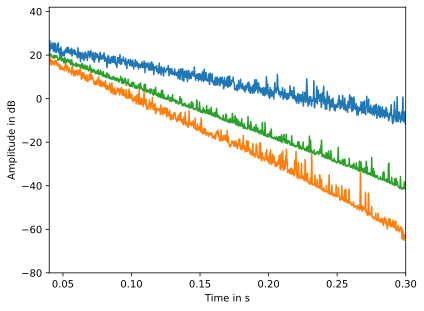

In [16]:
max_time = 0.3        # maximum propagation time to simulate, in seconds
sampling_rate = 5000  # time bins per second
time_bins = int(max_time * sampling_rate)

rendered_frequencies = [100, 500, 20000]  # must stay within the range of the material spectra defined above
rendered_frequencies_str = ', '.join(map(str, rendered_frequencies))

spp = 2**20  # rays per frequency

microphone = mi.load_dict({
    'type': 'microphone',
    'origin': receiver_pos,
    'direction': emitter_pos,
    'film': {
        'type': 'tape',
        'frequencies': rendered_frequencies_str,
        'time_bins': time_bins,
    },
})

integrator_acoustic = mi.load_dict({
    'type': 'acoustic_path',
    'max_depth': -1,
    'max_time': max_time,
    'speed_of_sound': 343.0, # set this explicitly to avoid an derived speed from the medium
    'acoustic_medium': {
        'apply_attenuation': False, # disable atmospheric attenuation (set True by default)
    }
})

etc = mi.render(scene, sensor=microphone, integrator=integrator_acoustic, spp=spp)

plot_etc(etc, sampling_rate, max_time, dB=True, bottom=-80)

## Rendering with atmospheric data

Atmospheric parameters (temperature, humidity, pressure, ...) are turned into a speed of sound via [`mitsuba.acoustic.speed_of_sound`](../shoebox_scene.ipynb). The same parameters are then handed directly to the `acoustic_path` integrator via its `acoustic_medium` parameter, with `apply_attenuation=True` (the default). The integrator attenuates every path contribution using its true accumulated *geometric* path distance, before it is binned in time -- more accurate than deriving distance from a time bin's index after the fact.

In [17]:
# Parameters describing the propagation medium (air)
temperature = 25.0    # degrees Celsius
relative_humidity = 0.6      # in the range [0, 1]
atmospheric_pressure = 101825.0  # Pascal
saturation_vapor_pressure = 610.78 * 10 ** (7.5 * temperature / (temperature + 237.3))  # Pascal
co2_ppm = 400.0     # parts per million

speed_of_sound_method = 'simple'  # available: 'simple' (default), 'ideal_gas', 'cramer'

speed_of_sound_atmo = mi.acoustic.speed_of_sound(
    temperature=temperature,                             # must be provided
    relative_humidity=relative_humidity,                  # optional
    atmospheric_pressure=atmospheric_pressure,             # optional
    saturation_vapor_pressure=saturation_vapor_pressure,   # optional
    co2_ppm=co2_ppm,                                       # optional
    method=speed_of_sound_method)

speed_of_sound_atmo = float(speed_of_sound_atmo[0]) # convert from gradient array to float (see ../inverse_rendering/atmosphere_optimization.ipynb)
print(f'speed_of_sound_atmo = {speed_of_sound_atmo} m/s (vs. the default 343 m/s)')

speed_of_sound_atmo = 346.1144714355469 m/s (vs. the default 343 m/s)


### Inline rendering

The atmospheric parameters are handed directly to the integrator via its `acoustic_medium` parameter — note that this is a *different* key from mitsuba's existing `medium` plugin parameter used for participating media (fog, etc.), which is unrelated. `speed_of_sound_method` and `apply_attenuation` live *inside* `acoustic_medium` too, since they only make sense together with it. We do **not** set `speed_of_sound` here — leaving it unset makes the integrator derive it from `acoustic_medium` internally. If `speed_of_sound` *is* set explicitly, it always wins, regardless of `acoustic_medium` (with a warning logged if both are given).

In [18]:
integrator_acoustic_atmo_auto = mi.load_dict({
    'type': 'acoustic_path',
    # 'speed_of_sound': ...,  # if set, this would override the value derived from 'acoustic_medium'
    'acoustic_medium': {
        'temperature': temperature,                            # must be provided
        'relative_humidity': relative_humidity,                # optional
        'atmospheric_pressure': atmospheric_pressure,           # optional
        'saturation_vapor_pressure': saturation_vapor_pressure, # optional
        'co2_ppm': co2_ppm,                                     # optional
        'speed_of_sound_method': speed_of_sound_method,
        'apply_attenuation': True,  # default once 'acoustic_medium' is set; set False to only use it for the speed of sound
    },
    'max_depth': -1,
    'max_time': max_time,
})
print(integrator_acoustic_atmo_auto)

etc_atmo_auto = mi.render(scene, sensor=microphone, integrator=integrator_acoustic_atmo_auto, spp=spp)

AcousticPathIntegrator[
  speed_of_sound = [346.114]
  max_time = 0.3
  max_depth = disabled
  rr_depth = 100000
  max_energy_loss = 60.000000 dB
  hide_emitters = 0
  apply_attenuation = 1
]


### You don't know all the parameters for your scene? ... No worries!

<div class="admonition important alert alert-block alert-info">

💡 **Misuka relies on a standard medium containing default values for each atmospheric parameter not provided.**

The Standard medium is defined as:

| parameter | value |
|---|---|
| temperature | 25.0 °C |
| relative humidity | 0.6 (60%) |
| atmospheric pressure | 101 825 Pa |
| saturation vapor pressure | ≈ 3167 Pa (Magnus formula from temperature, see the constant's definition) |
| CO2 concentration | 400.0 ppm |

</div>


## Runtime cost of inline attenuation

A real runtime analysis would be a little too much for this notebook. For reference, the latest version has been benchmarked separately and found to have no statistically significant runtime differences with attenuation enabled vs. disabled, with variant llvm_ad_acoustic. Though on average big rooms like the BRAS auditorium showed an average of ≈1.1% higher runtime with attenuation enabled vs disabled.

## Comparing the results

We reuse the `plot_etc` helper defined above to plot each ETC in dB.

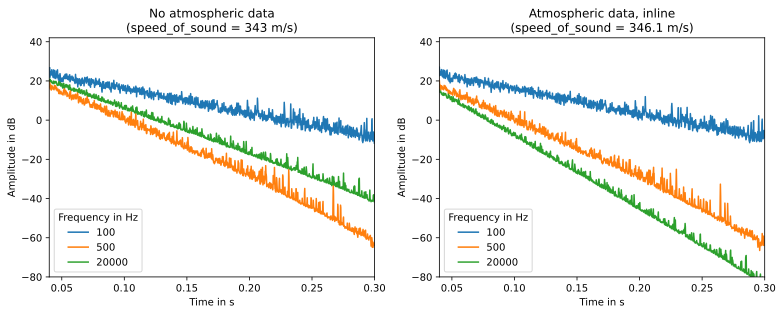

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

plt.sca(axes[0])
plot_etc(etc, sampling_rate, max_time, dB=True, bottom=-80)
axes[0].set_title('No atmospheric data\n(speed_of_sound = 343 m/s)')
axes[0].legend(rendered_frequencies, title='Frequency in Hz')

plt.sca(axes[1])
plot_etc(etc_atmo_auto, sampling_rate, max_time, dB=True, bottom=-80)
axes[1].set_title('Atmospheric data, inline\n(speed_of_sound = %.1f m/s)' % speed_of_sound_atmo)
axes[1].legend(rendered_frequencies, title='Frequency in Hz')

plt.tight_layout()
plt.show()

High frequencies decay noticeably faster once atmospheric attenuation is applied — as expected from ISO 9613-1, air absorption grows sharply with frequency.

## Summary

<div class="admonition important alert alert-block alert-success">

🚀 **Takeaways:**

<ul>
  <li>Atmospheric parameters can be handed directly to the <code>acoustic_path</code> integrator via <code>acoustic_medium</code>, which applies both the resulting speed of sound and (by default) frequency-dependent air attenuation inline, during rendering -- using each path's true geometric distance rather than a time-bin-implied one.</li>
  <li>An explicit <code>speed_of_sound</code> on the integrator always takes priority over <code>acoustic_medium</code> (a warning is logged if both are given); without it, the integrator derives the speed of sound from <code>acoustic_medium</code> using its nested <code>speed_of_sound_method</code>.</li>
</ul>

</div>